In [32]:
# =========================================================
# 1. IMPORT LIBRARY
# =========================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.linear_model import LinearRegression
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    mean_squared_error,
    mean_absolute_percentage_error,
    silhouette_score
)
from sklearn.decomposition import PCA

In [33]:
# =========================================================
# 2. LOAD DATA
# =========================================================

df = pd.read_excel("D:/MAGANG/Data IKM Magang.xlsx")
df


,No,Tanggal,Persyaratan,Prosedur pelayanan,Waktu,Biaya/tarif,Produk pelayanan,Kompetensi/kemampuan,Perilaku petugas sopan dan ramah,Kualitas sarana dan prasarana,Penanganan pengaduan,IKM Konversi,Jumlah Orang
0,1,2023-01-01,"3,80","3,76","3,99","3,77","4,00","3,81","3,81","3,89","3,80","96,19",277
1,2,2023-02-01,"3,92","3,92","3,88","4,00","3,92","3,96","3,88","3,83","3,96","97,92",24
2,3,2023-03-01,"3,57","3,59","3,54","4,00","3,54","3,54","3,59","3,51","3,53","90,01",189
3,4,2023-04-01,"3,74","3,74","3,69","4,00","3,68","3,71","3,78","3,69","3,68","93,64",114
4,5,2023-05-01,"3,58","3,56","3,55","4,00","3,48","3,51","3,56","3,43","3,44","89,16",227
5,6,2023-06-01,"3,74","3,76","3,74","4,00","3,71","3,73","3,72","3,65","3,71","93,75",282
6,7,2023-07-01,"3,81","3,81","3,80","4,00","3,81","3,80","3,82","3,79","3,79","95,66",117
7,8,2023-08-01,"3,82","3,80","3,79","4,00","3,79","3,77","3,79","3,79","3,77","95,36",136
8,9,2023-09-01,"3,96","3,95","3,96","4,00","3,96","3,96","3,98","3,97","3,99","99,29",107
9,10,2023-10-01,"3,83","3,84","3,84","4,00","3,81","3,82","3,83","3,80","3,81","96,05",126


In [34]:
# =========================================================
# 3. MEMBERSIHKAN NAMA KOLOM
# =========================================================

df.columns = (
    df.columns
    .str.strip()
    .str.replace('\n', ' ')
)

In [35]:
# =========================================================
# 4. MENAMPILKAN NAMA KOLOM
# =========================================================

print("====================================")
print("NAMA KOLOM DATASET")
print("====================================")

print(df.columns.tolist())

NAMA KOLOM DATASET
['No', 'Tanggal', 'Persyaratan', 'Prosedur pelayanan', 'Waktu', 'Biaya/tarif', 'Produk pelayanan', 'Kompetensi/kemampuan', 'Perilaku petugas sopan dan ramah', 'Kualitas sarana dan prasarana', 'Penanganan pengaduan', 'IKM Konversi', 'Jumlah Orang']


In [36]:
# =========================================================
# 5. FITUR YANG DIGUNAKAN
# =========================================================

fitur = [
    'Persyaratan',
    'Prosedur pelayanan',
    'Waktu',
    'Biaya/tarif',
    'Produk pelayanan',
    'Kompetensi/kemampuan',
    'Perilaku petugas sopan dan ramah',
    'Kualitas sarana dan prasarana',
    'Penanganan pengaduan'
]

In [37]:
# =========================================================
# 6. MEMBERSIHKAN DATA NUMERIK
# =========================================================

# kolom numerik
kolom_numerik = fitur + ['IKM Konversi']

for col in kolom_numerik:

    df[col] = (
        df[col]
        .astype(str)
        .str.replace(',', '.')
        .astype(float)
    )

In [38]:
# =========================================================
# 7. PREPROCESSING TANGGAL
# =========================================================

df['Tanggal'] = pd.to_datetime(df['Tanggal'])

# urutkan berdasarkan tanggal
df = df.sort_values('Tanggal')

# membuat index waktu
df['bulan_ke'] = np.arange(len(df))

In [39]:
# =========================================================
# 8. MENAMPILKAN INFO DATA
# =========================================================

print("\n====================================")
print("INFO DATA")
print("====================================")

print(df.info())


INFO DATA
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 37 entries, 0 to 36
Data columns (total 14 columns):
 #   Column                            Non-Null Count  Dtype         
---  ------                            --------------  -----         
 0   No                                37 non-null     int64         
 1   Tanggal                           37 non-null     datetime64[ns]
 2   Persyaratan                       37 non-null     float64       
 3   Prosedur pelayanan                37 non-null     float64       
 4   Waktu                             37 non-null     float64       
 5   Biaya/tarif                       37 non-null     float64       
 6   Produk pelayanan                  37 non-null     float64       
 7   Kompetensi/kemampuan              37 non-null     float64       
 8   Perilaku petugas sopan dan ramah  37 non-null     float64       
 9   Kualitas sarana dan prasarana     37 non-null     float64       
 10  Penanganan pengaduan              37 non-

In [40]:
# =========================================================
# 9. DESKRIPSI STATISTIK
# =========================================================

print("\n====================================")
print("DESKRIPSI STATISTIK")
print("====================================")

print(df.describe())


DESKRIPSI STATISTIK
              No                        Tanggal  Persyaratan  \
count  37.000000                             37    37.000000   
mean   19.000000  2024-07-01 08:25:56.756756736     3.881351   
min     1.000000            2023-01-01 00:00:00     3.570000   
25%    10.000000            2023-10-01 00:00:00     3.830000   
50%    19.000000            2024-07-01 00:00:00     3.920000   
75%    28.000000            2025-04-01 00:00:00     3.960000   
max    37.000000            2026-01-01 00:00:00     4.000000   
std    10.824355                            NaN     0.113043   

       Prosedur pelayanan      Waktu  Biaya/tarif  Produk pelayanan  \
count           37.000000  37.000000    37.000000         37.000000   
mean             3.874865   3.864324     3.993784          3.871892   
min              3.560000   3.540000     3.770000          3.480000   
25%              3.840000   3.800000     4.000000          3.810000   
50%              3.910000   3.890000     4.0000

In [41]:
# =========================================================
# 10. CEK MISSING VALUE
# =========================================================

print("\n====================================")
print("MISSING VALUE")
print("====================================")

print(df.isnull().sum())


MISSING VALUE
No                                  0
Tanggal                             0
Persyaratan                         0
Prosedur pelayanan                  0
Waktu                               0
Biaya/tarif                         0
Produk pelayanan                    0
Kompetensi/kemampuan                0
Perilaku petugas sopan dan ramah    0
Kualitas sarana dan prasarana       0
Penanganan pengaduan                0
IKM Konversi                        0
Jumlah Orang                        0
bulan_ke                            0
dtype: int64


# Forecasting

In [42]:
# =========================================================
# 1. MENENTUKAN X DAN Y
# =========================================================

X_forecast = df[['bulan_ke']]
y_forecast = df['IKM Konversi']

In [43]:
# =========================================================
# 2. MEMBUAT MODEL REGRESI LINEAR
# =========================================================

model = LinearRegression()

# training model
model.fit(X_forecast, y_forecast)

LinearRegression()

In [44]:
# =========================================================
# 3. PREDIKSI DATA
# =========================================================

df['Prediksi'] = model.predict(X_forecast)

In [45]:
# =========================================================
# 4. EVALUASI RMSE
# =========================================================

rmse = np.sqrt(
    mean_squared_error(
        y_forecast,
        df['Prediksi']
    )
)


In [46]:
# =========================================================
# 5. EVALUASI MAPE
# =========================================================

mape = mean_absolute_percentage_error(
    y_forecast,
    df['Prediksi']
) * 100

In [47]:
# =========================================================
# 6. HASIL EVALUASI
# =========================================================

print("\n====================================")
print("HASIL EVALUASI FORECASTING")
print("====================================")

print(f"RMSE : {rmse:.4f}")
print(f"MAPE : {mape:.2f}%")


HASIL EVALUASI FORECASTING
RMSE : 2.3272
MAPE : 1.90%


In [48]:
# =========================================================
# 7. INTERPRETASI MAPE
# =========================================================

if mape < 10:
    print("Model Sangat Baik")

elif mape < 20:
    print("Model Baik")

elif mape < 50:
    print("Model Cukup")

else:
    print("Model Kurang Baik")

Model Sangat Baik


In [49]:
# =========================================================
# 8. FORECAST 6 BULAN KE DEPAN
# =========================================================

future = pd.DataFrame({
    'bulan_ke': np.arange(len(df), len(df)+6)
})

future_pred = model.predict(future)

In [50]:
# =========================================================
# 9. MEMBUAT TANGGAL FORECAST
# =========================================================

last_date = df['Tanggal'].max()

future_dates = pd.date_range(
    start=last_date,
    periods=7,
    freq='M'
)[1:]

In [51]:
# =========================================================
# 10. DATAFRAME FORECAST
# =========================================================

forecast_df = pd.DataFrame({
    'Tanggal': future_dates,
    'Forecast_IKM': future_pred
})

print("\n====================================")
print("HASIL FORECAST 6 BULAN")
print("====================================")

print(forecast_df)



HASIL FORECAST 6 BULAN
     Tanggal  Forecast_IKM
0 2026-02-28     99.532793
1 2026-03-31     99.659256
2 2026-04-30     99.785718
3 2026-05-31     99.912181
4 2026-06-30    100.038644
5 2026-07-31    100.165107


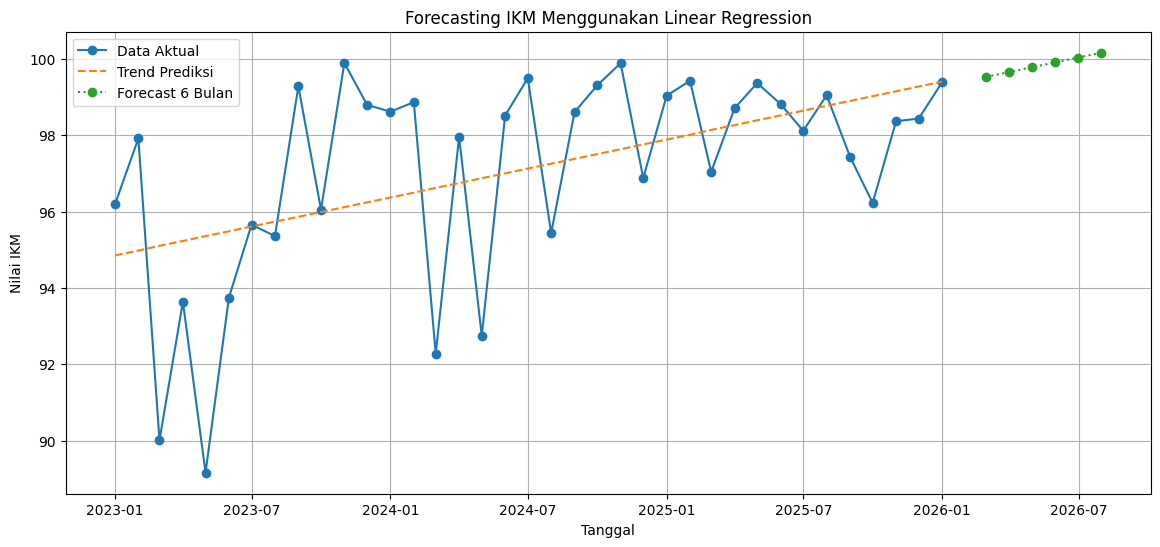

In [52]:
# =========================================================
# 11. VISUALISASI FORECASTING
# =========================================================

plt.figure(figsize=(14,6))

# data aktual
plt.plot(
    df['Tanggal'],
    df['IKM Konversi'],
    marker='o',
    label='Data Aktual'
)

# trend prediksi
plt.plot(
    df['Tanggal'],
    df['Prediksi'],
    linestyle='--',
    label='Trend Prediksi'
)

# forecast masa depan
plt.plot(
    forecast_df['Tanggal'],
    forecast_df['Forecast_IKM'],
    marker='o',
    linestyle=':',
    label='Forecast 6 Bulan'
)

plt.title('Forecasting IKM Menggunakan Linear Regression')

plt.xlabel('Tanggal')
plt.ylabel('Nilai IKM')

plt.legend()
plt.grid(True)

plt.show()